## Prediction Using the model fiel .h5 for normal Use

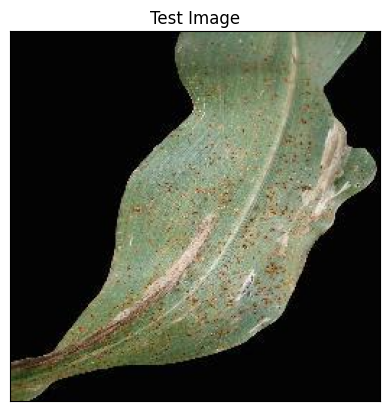

1/1 [==============================] - 0s 107ms/step
Predicted class: Corn_(maize)___Common_rust_
Confidence: 0.9999455


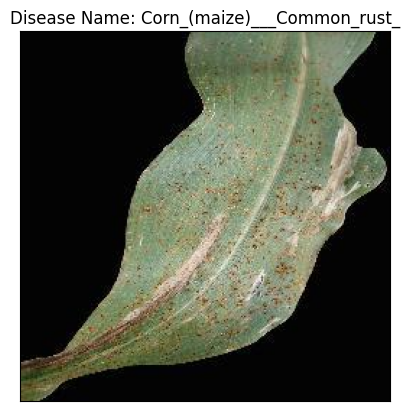

In [14]:
import tensorflow as tf
import numpy as np
import cv2

# Image size used during training
IMG_SIZE = 64

# Load trained model
model = tf.keras.models.load_model("light_version/plant_disease_model.h5")

# Class names (automatically taken from training folder)
class_names = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

# Load image
# image_path = "test_image.jpg"
# image_path = "test/test/AppleCedarRust1.JPG"
image_path = "test/test/CornCommonRust1.JPG"

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# showing the image here
#Display Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])  # to remove the numbering on the x axis
plt.yticks([])
plt.show()


img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img / 255.0

# Add batch dimension
img = np.expand_dims(img, axis=0)

# Prediction
prediction = model.predict(img)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print("Predicted class:", predicted_class)
print("Confidence:", confidence)


# showing the name over the image 

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title(f"Disease Name: {predicted_class}")
plt.xticks([])  # to remove the numbering on the x axis
plt.yticks([])
plt.show()

## Prediction using .tflite for ESP32 

Input Details: [{'name': 'serving_default_conv2d_2_input:0', 'index': 0, 'shape': array([ 1, 64, 64,  3]), 'shape_signature': array([-1, 64, 64,  3]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output Details: [{'name': 'StatefulPartitionedCall:0', 'index': 21, 'shape': array([ 1, 38]), 'shape_signature': array([-1, 38]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


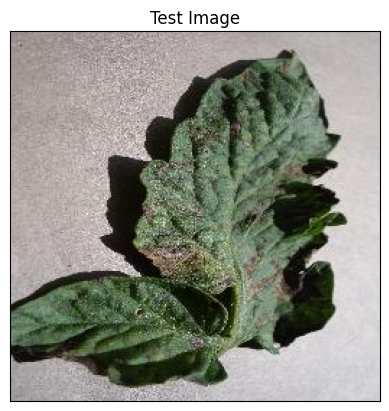

Predicted class: Tomato___Early_blight
Confidence: 0.53837377


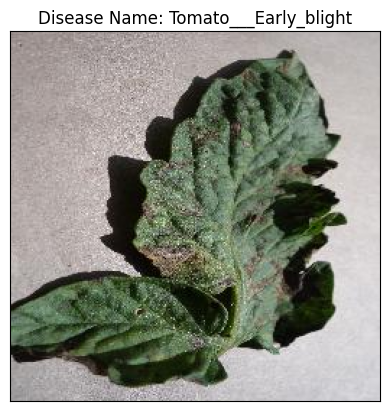

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG_SIZE = 64

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="light_version/plant_disease_model_lite_version.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()



# Class names
class_names = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

# Load image
# image_path = "test/test/CornCommonRust1.JPG"
image_path = "test/test/PotatoEarlyBlight2.JPG"
image_path = "test/test/TomatoEarlyBlight5.JPG"

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# showing the image here
#Display Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])  # to remove the numbering on the x axis
plt.yticks([])
plt.show()


img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img / 255.0
img = np.expand_dims(img, axis=0).astype(np.float32)

# Set input tensor
interpreter.set_tensor(input_details[0]['index'], img)

# Run inference
interpreter.invoke()

# Get prediction
output_data = interpreter.get_tensor(output_details[0]['index'])

predicted_index = np.argmax(output_data)
confidence = np.max(output_data)

predicted_class = class_names[predicted_index]

print("Predicted class:", predicted_class)
print("Confidence:", confidence)

# showing the name over the image 

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title(f"Disease Name: {predicted_class}")
plt.xticks([])  # to remove the numbering on the x axis
plt.yticks([])
plt.show()

Input Details: [{'name': 'serving_default_conv2d_2_input:0', 'index': 0, 'shape': array([ 1, 64, 64,  3]), 'shape_signature': array([-1, 64, 64,  3]), 'dtype': <class 'numpy.uint8'>, 'quantization': (0.003921568859368563, 0), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([0]), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output Details: [{'name': 'StatefulPartitionedCall:0', 'index': 23, 'shape': array([ 1, 38]), 'shape_signature': array([-1, 38]), 'dtype': <class 'numpy.uint8'>, 'quantization': (0.00390625, 0), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([0]), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


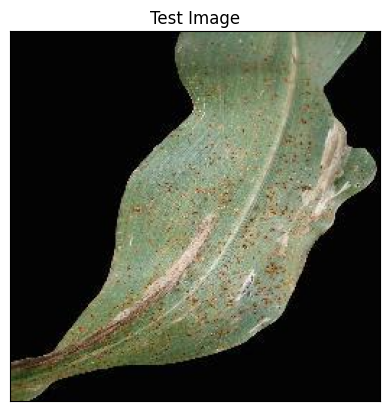

Predicted class: Corn_(maize)___Common_rust_
Confidence: 1.0


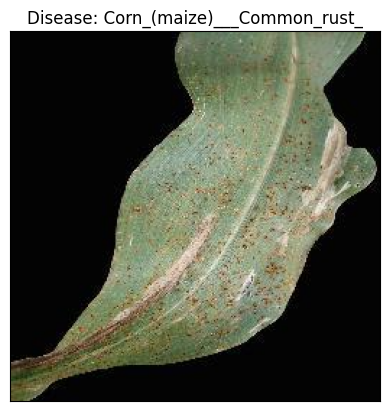

In [20]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG_SIZE = 64

# Load TFLite INT8 model
interpreter = tf.lite.Interpreter(
    model_path="light_version/plant_disease_tiny_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input Details:",input_details)
print("Output Details:",output_details)

# Class names
class_names = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

# Load image
# image_path = "test/test/TomatoEarlyBlight5.JPG"
image_path = "test/test/CornCommonRust1.JPG"

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show original image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

# Resize for model
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

# Convert to uint8 (INT8 model requirement)
img_input = np.expand_dims(img_resized, axis=0).astype(np.uint8)

# Set input tensor
interpreter.set_tensor(input_details[0]['index'], img_input)

# Run inference
interpreter.invoke()

# Get prediction
output_data = interpreter.get_tensor(output_details[0]['index'])

predicted_index = np.argmax(output_data)
predicted_class = class_names[predicted_index]
confidence = output_data[0][predicted_index] / 255.0

print("Predicted class:", predicted_class)
print("Confidence:", confidence)

# Show result on image
plt.imshow(img)
plt.title(f"Disease: {predicted_class}")
plt.xticks([])
plt.yticks([])
plt.show()

In [11]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG_SIZE = 64

# Load TFLite INT8 model
interpreter = tf.lite.Interpreter(
    model_path="final_light_version/plant_disease_tiny_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input Details:",input_details)
print("Output Details:",output_details)

# Class names
class_names = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

# Load image
# image_path = "test/test/TomatoEarlyBlight5.JPG"
image_path = "test/test/CornCommonRust1.JPG"

img = cv2.imread(image_path)

print(img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show original image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

# Resize for model
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

# Convert to uint8 (INT8 model requirement)
img_input = np.expand_dims(img_resized, axis=0).astype(np.uint8)

# Set input tensor
interpreter.set_tensor(input_details[0]['index'], img_input)

# Run inference
interpreter.invoke()

# Get prediction
output_data = interpreter.get_tensor(output_details[0]['index'])

predicted_index = np.argmax(output_data)
predicted_class = class_names[predicted_index]
confidence = output_data[0][predicted_index] / 255.0

print("Predicted class:", predicted_class)
print("Confidence:", confidence)

# Show result on image
plt.imshow(img)
plt.title(f"Disease: {predicted_class}")
plt.xticks([])
plt.yticks([])
plt.show()

Input Details: [{'name': 'serving_default_input_8:0', 'index': 0, 'shape': array([ 1, 64, 64,  3]), 'shape_signature': array([-1, 64, 64,  3]), 'dtype': <class 'numpy.uint8'>, 'quantization': (0.003921568859368563, 0), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([0]), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output Details: [{'name': 'StatefulPartitionedCall:0', 'index': 23, 'shape': array([ 1, 38]), 'shape_signature': array([-1, 38]), 'dtype': <class 'numpy.uint8'>, 'quantization': (0.00390625, 0), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([0]), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
None


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [ ]:
xxd -i final_light_version/plant_disease_tiny_int8.tflite > model.h

## This is the State of the art Model with 94% Efficiency With Small space size 

Input Details: [{'name': 'serving_default_input_10:0', 'index': 0, 'shape': array([ 1, 64, 64,  3]), 'shape_signature': array([-1, 64, 64,  3]), 'dtype': <class 'numpy.uint8'>, 'quantization': (0.003921568859368563, 0), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([0]), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output Details: [{'name': 'StatefulPartitionedCall:0', 'index': 23, 'shape': array([ 1, 38]), 'shape_signature': array([-1, 38]), 'dtype': <class 'numpy.uint8'>, 'quantization': (0.00390625, 0), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([0]), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


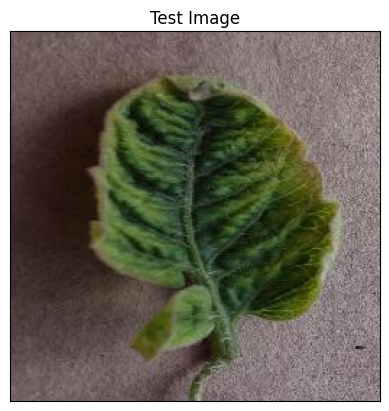

Predicted class: Tomato___Early_blight
Confidence: 0.48627450980392156


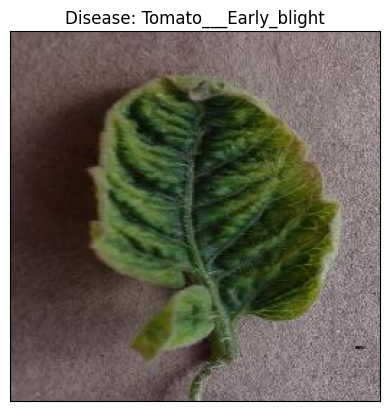

In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG_SIZE = 64

# Load TFLite INT8 model
interpreter = tf.lite.Interpreter(
    model_path="pretrained_final_light_version/plant_disease_tiny_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input Details:",input_details)
print("Output Details:",output_details)

# Class names
class_names = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

# Load image
# image_path = "test/test/TomatoEarlyBlight5.JPG"
# image_path = "test/test/CornCommonRust1.JPG"
# image_path = "test/test/PotatoEarlyBlight5.JPG"
# image_path = "test/PotatoHealthy2.JPG"
# image_path = "test/test/TomatoEarlyBlight6.JPG"
image_path = "test/TomatoYellowCurlVirus2.JPG"
# image_path = "test/AppleScab3.JPG"
# image_path = "test/PotatoEarlyBlight4.JPG"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show original image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

# Resize for model
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

# Convert to uint8 (INT8 model requirement)
img_input = np.expand_dims(img_resized, axis=0).astype(np.uint8)

# Set input tensor
interpreter.set_tensor(input_details[0]['index'], img_input)

# Run inference
interpreter.invoke()

# Get prediction
output_data = interpreter.get_tensor(output_details[0]['index'])

predicted_index = np.argmax(output_data)
predicted_class = class_names[predicted_index]
confidence = output_data[0][predicted_index] / 255.0

print("Predicted class:", predicted_class)
print("Confidence:", confidence)

# Show result on image
plt.imshow(img)
plt.title(f"Disease: {predicted_class}")
plt.xticks([])
plt.yticks([])
plt.show()